# Mueller Matrix Tissue Segmentation
**Classes:**
- Class 0: Background
- Class 1: Tissue (general)
- Class 2: OS
- Class 3: Vaginal

**Before running:**
1. Update `DATA_DIR`
2. Adjust `BATCH_SIZE` based on GPU

## 1. Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.models as models
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm.auto import tqdm
import json
import warnings
import random

warnings.filterwarnings('ignore')

# Reproducibility
def set_seed(seed):
    """Set random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

print("✓ Imports successful")

✓ Imports successful


C:\Users\user_picm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [2]:
class Config:
    """Training Configuration"""

    # === PATHS ===
    DATA_DIR = Path("F:/MPL_Data/mmNoTissueFilter/TRIMMM")
    OUTPUT_DIR = Path("../../models")

    # === MODEL ===
    ENCODER_NAME = 'resnet34'
    USE_PRETRAINED = True
    INPUT_SIZE = (512, 512)

    # === TRAINING ===
    BATCH_SIZE = 8
    NUM_EPOCHS = 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE = 15

    # === DATA SPLIT ===
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    RANDOM_SEED = 42

    # Kept in the dataset for publication (see CHANGELOG.md 2026-07-22/23 entry for the
    # earlier exclusion experiment and why it was reverted).
    EXCLUDED_SAMPLES = []

    # === AUGMENTATION ===
    INTENSITY_JITTER = 0.15  # +/- 15% brightness variation

    # === GPU ===
    USE_GPU = True
    USE_MIXED_PRECISION = True
    NUM_WORKERS = 0

    # Setup device
    if USE_GPU and torch.cuda.is_available():
        DEVICE = torch.device('cuda')
        print(f"✓ Using GPU: {torch.cuda.get_device_name(0)}")
    else:
        DEVICE = torch.device('cpu')
        print("✓ Using CPU")

set_seed(Config.RANDOM_SEED)
Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("✓ Configuration complete")

✓ Using GPU: NVIDIA RTX 5000 Ada Generation Laptop GPU
✓ Configuration complete


## 3. Data Loading & Parsing

In [3]:
def discover_samples(data_dir: Path) -> List[Dict]:
    """Discover samples and identify their parent groups"""
    if not data_dir.exists():
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    samples = []
    parent_dirs = [d for d in data_dir.iterdir() if d.is_dir() and not d.name.startswith('.')]

    print(f"Scanning {len(parent_dirs)} parent directories...")

    for parent_dir in parent_dirs:
        group_id = parent_dir.name
        sample_dirs = [d for d in parent_dir.iterdir() if d.is_dir() and not d.name.startswith('.')]

        # Group variations (rot/flip) under one unique sample name
        sample_groups = {}
        for sample_dir in sample_dirs:
            name = sample_dir.name
            base_name = name
            for suffix in ['_original', '_rot90', '_rot180', '_rot270', '_flip_h', '_flip_v']:
                base_name = base_name.replace(suffix, '')

            unique_name = f"{parent_dir.name}_{base_name}"

            if unique_name not in sample_groups:
                sample_groups[unique_name] = []
            sample_groups[unique_name].append(sample_dir)

        for unique_name, dirs in sample_groups.items():
            # Only pick the _original folder
            selected_dir = next((d for d in dirs if '_original' in d.name), dirs[0])
            npz_files = [f for f in selected_dir.glob("*.npz") if not f.name.startswith('.')]

            if npz_files:
                samples.append({
                    'sample_name': unique_name,
                    'group_id': group_id,
                    'npz_path': npz_files[0]
                })

    return samples


def extract_m11_and_mask(npz_path: Path) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """Extract M11 and Mask. Normalizes M11 to 0-1 range and handles NaN/Inf values."""
    try:
        with np.load(npz_path, allow_pickle=True) as data:
            # 1. Get M11
            m11 = None
            if 'nM11s' in data:
                m11 = np.array(data['nM11s'])
            elif 'M11s' in data:
                m11_raw = np.array(data['M11s'])
                # Min-Max normalize to 0-1
                if m11_raw.max() > m11_raw.min():
                    m11 = (m11_raw - m11_raw.min()) / (m11_raw.max() - m11_raw.min())
                else:
                    m11 = np.zeros_like(m11_raw)

            if m11 is None or m11.ndim != 2:
                return None

            # Handle NaN and Inf values - replace with 0
            m11 = np.nan_to_num(m11, nan=0.0, posinf=0.0, neginf=0.0)

            # 2. Get Masks
            tissue_mask = None
            for key in ['tissue_mask', 'annotation_mask']:
                if key in data:
                    tissue_mask = np.array(data[key]) > 0
                    break

            if tissue_mask is None:
                return None

            os_mask = np.array(data['os_mask']) > 0 if 'os_mask' in data else None
            
            # Vaginal mask - check multiple possible keys
            vag_mask = None
            for key in ['vaginal_mask', 'vaginal_wall', 'vaginal_wall_mask']:
                if key in data:
                    vag_mask = np.array(data[key]) > 0
                    break

            # 3. Combine Priorities: Vaginal(3) > OS(2) > Tissue(1) > Background(0)
            combined_mask = np.zeros_like(tissue_mask, dtype=np.int64)
            combined_mask[tissue_mask] = 1
            if os_mask is not None:
                combined_mask[os_mask] = 2
            if vag_mask is not None:
                combined_mask[vag_mask] = 3

            return m11.astype(np.float32), combined_mask.astype(np.int64)
    except Exception as e:
        print(f"Error loading {npz_path.name}: {e}")
        return None

print("✓ Data loading functions defined")

✓ Data loading functions defined


## 4. Dataset Class with ImageNet Normalization & Augmentation

In [4]:
class M11Dataset(Dataset):
    """Dataset for M11 images with ImageNet normalization and augmentation"""
    
    def __init__(self, samples, input_size=(512, 512), augment=False, intensity_jitter=0.0):
        self.samples = samples
        self.input_size = input_size
        self.augment = augment
        self.intensity_jitter = intensity_jitter

        # ImageNet normalization (matches inference preprocessing)
        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)

        # Pre-load data for faster training
        self.data = []
        for s in tqdm(samples, desc="Loading samples"):
            res = extract_m11_and_mask(s['npz_path'])
            if res:
                self.data.append(res)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        m11, mask = self.data[idx]

        # Resize to target size
        m11 = self._resize(m11, is_mask=False)
        mask = self._resize(mask, is_mask=True)

        # Apply augmentation if enabled
        if self.augment:
            # Geometric augmentation
            if np.random.rand() > 0.5:
                m11 = np.fliplr(m11)
                mask = np.fliplr(mask)
            if np.random.rand() > 0.5:
                m11 = np.flipud(m11)
                mask = np.flipud(mask)
            k = np.random.randint(0, 4)
            if k > 0:
                m11 = np.rot90(m11, k)
                mask = np.rot90(mask, k)

            # Intensity augmentation (brightness variation)
            if self.intensity_jitter > 0:
                factor = 1.0 + np.random.uniform(-self.intensity_jitter, self.intensity_jitter)
                m11 = np.clip(m11 * factor, 0.0, 1.0)

        # Convert to 3-channel RGB (replicate grayscale)
        m11_rgb = np.stack([m11, m11, m11], axis=0)  # [3, H, W]

        # Apply ImageNet normalization
        m11_normalized = (m11_rgb - self.mean) / self.std

        return torch.from_numpy(m11_normalized).float(), torch.from_numpy(mask.copy()).long()

    def _resize(self, img, is_mask):
        """Resize image or mask to target size"""
        t = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)
        if is_mask:
            res = F.interpolate(t, size=self.input_size, mode='nearest')
        else:
            res = F.interpolate(t, size=self.input_size, mode='bilinear', align_corners=True)
        return res.squeeze().numpy().astype(np.int64 if is_mask else np.float32)

print("✓ Dataset class defined")

✓ Dataset class defined


## 5. Prepare Data (Stratified Split - Balanced Days)

In [5]:
from sklearn.model_selection import StratifiedShuffleSplit

# Discover all samples
all_samples = discover_samples(Config.DATA_DIR)
print(f"✓ Found {len(all_samples)} total samples")

# Drop excluded samples from the pool before splitting (see Config.EXCLUDED_SAMPLES)
n_before = len(all_samples)
all_samples = [s for s in all_samples if s['sample_name'] not in Config.EXCLUDED_SAMPLES]
n_excluded = n_before - len(all_samples)
if n_excluded:
    print(f"✓ Excluded {n_excluded} sample(s) from the pool: {Config.EXCLUDED_SAMPLES}")
    print(f"  Remaining samples: {len(all_samples)}")

# Perform stratified split based on group_id (Day)
# This ensures each day is represented proportionally in train/val/test
groups = [s['group_id'] for s in all_samples]

# Split 1: Separate Train vs Temp (Val+Test)
splitter = StratifiedShuffleSplit(
    n_splits=1, 
    test_size=Config.VAL_RATIO + Config.TEST_RATIO, 
    random_state=Config.RANDOM_SEED
)
train_idx, temp_idx = next(splitter.split(all_samples, groups))

train_subset = [all_samples[i] for i in train_idx]
temp_subset = [all_samples[i] for i in temp_idx]

# Split 2: Separate Val vs Test
temp_groups = [temp_subset[i]['group_id'] for i in range(len(temp_subset))]
splitter_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=Config.RANDOM_SEED)
val_idx, test_idx = next(splitter_val.split(temp_subset, temp_groups))

val_subset = [temp_subset[i] for i in val_idx]
test_subset = [temp_subset[i] for i in test_idx]

print(f"\nData Split:")
print(f"  Train: {len(train_subset)} samples ({len(train_subset)/len(all_samples)*100:.1f}%)")
print(f"  Val:   {len(val_subset)} samples ({len(val_subset)/len(all_samples)*100:.1f}%)")
print(f"  Test:  {len(test_subset)} samples ({len(test_subset)/len(all_samples)*100:.1f}%)")

# Create datasets with ImageNet normalization
print(f"\n✓ Using ImageNet normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])")

train_ds = M11Dataset(train_subset, augment=True, intensity_jitter=Config.INTENSITY_JITTER)
val_ds = M11Dataset(val_subset, augment=False)
test_ds = M11Dataset(test_subset, augment=False)

# Create data loaders
train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, num_workers=Config.NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=Config.BATCH_SIZE, num_workers=Config.NUM_WORKERS)

# Display test set manifest
print("\n" + "="*70)
print("TEST SET SAMPLES (Balanced across Days)")
print("="*70)
sorted_test = sorted(test_subset, key=lambda x: x['group_id'])
for s in sorted_test:
    print(f"  {s['group_id']:6s} | {s['sample_name']}")
print("="*70)

Scanning 7 parent directories...
✓ Found 74 total samples

Data Split:
  Train: 51 samples (68.9%)
  Val:   11 samples (14.9%)
  Test:  12 samples (16.2%)

✓ Using ImageNet normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


Loading samples:   0%|          | 0/51 [00:00<?, ?it/s]

Loading samples:   4%|▍         | 2/51 [00:00<00:07,  6.83it/s]

Loading samples:   8%|▊         | 4/51 [00:00<00:04,  9.93it/s]

Loading samples:  12%|█▏        | 6/51 [00:00<00:06,  6.55it/s]

...

Loading samples:  75%|███████▌  | 9/12 [00:01<00:00,  7.36it/s]

Loading samples:  83%|████████▎ | 10/12 [00:01<00:00,  6.48it/s]

Loading samples: 100%|██████████| 12/12 [00:01<00:00,  8.27it/s]

Loading samples: 100%|██████████| 12/12 [00:01<00:00,  7.37it/s]


TEST SET SAMPLES (Balanced across Days)
  Day0   | Day0_mm_results_Day0H_2B_S7
  Day0   | Day0_mm_results_Day0G_8B_S2
  Day12  | Day12_mm_results_Day12D_9B_S2
  Day13  | Day13_mm_results_D13D_S9A_5
  Day14  | Day14_mm_results_D14D_S8A_3
  Day15  | Day15_mm_results_D15C_S6A_2
  Day15  | Day15_mm_results_D15F_S6B_2
  Day15  | Day15_mm_results_Day15F_S6B_3
  Day15  | Day15_mm_results_D15F_S6B_5
  Day18  | Day18_mm_results_D18E_S2A_1
  Day6   | Day6_mm_results_Day6D_8B_S3
  Day6   | Day6_mm_results_day6_4


In [6]:
# Save data split for test analysis notebook
data_split_export = {
    'train': [{'name': s['sample_name'], 'path': str(s['npz_path'])} for s in train_subset],
    'val': [{'name': s['sample_name'], 'path': str(s['npz_path'])} for s in val_subset],
    'test': [{'name': s['sample_name'], 'path': str(s['npz_path'])} for s in test_subset]
}

split_file = Config.OUTPUT_DIR / 'data_split.json'
with open(split_file, 'w') as f:
    json.dump(data_split_export, f, indent=2)

print(f"✓ Data split saved to: {split_file}")

✓ Data split saved to: ..\..\models\data_split.json


## 6. Model & Training Components

In [7]:
class UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Using simple ResNet34
        self.encoder = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        self.enc_layers = list(self.encoder.children())

        self.enc1 = nn.Sequential(*self.enc_layers[:3]) # 64
        self.enc2 = nn.Sequential(*self.enc_layers[3:5]) # 64
        self.enc3 = self.enc_layers[5] # 128
        self.enc4 = self.enc_layers[6] # 256
        self.enc5 = self.enc_layers[7] # 512

        self.dec4 = self._block(512 + 256, 256)
        self.dec3 = self._block(256 + 128, 128)
        self.dec2 = self._block(128 + 64, 64)
        self.dec1 = self._block(64 + 64, 32)

        self.final = nn.Conv2d(32, num_classes, 1)

    def _block(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c), nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c), nn.ReLU()
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)

        d4 = F.interpolate(e5, size=e4.shape[2:], mode='bilinear')
        d4 = self.dec4(torch.cat([d4, e4], 1))

        d3 = F.interpolate(d4, size=e3.shape[2:], mode='bilinear')
        d3 = self.dec3(torch.cat([d3, e3], 1))

        d2 = F.interpolate(d3, size=e2.shape[2:], mode='bilinear')
        d2 = self.dec2(torch.cat([d2, e2], 1))

        d1 = F.interpolate(d2, size=e1.shape[2:], mode='bilinear')
        d1 = self.dec1(torch.cat([d1, e1], 1))

        out = F.interpolate(d1, scale_factor=2, mode='bilinear')
        return self.final(out)

class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()

    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)

        # Simple Dice
        pred_soft = F.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, num_classes=pred.shape[1]).permute(0,3,1,2)

        intersection = (pred_soft * target_one_hot).sum(dim=(2,3))
        union = pred_soft.sum(dim=(2,3)) + target_one_hot.sum(dim=(2,3))
        dice_score = (2. * intersection + 1) / (union + 1)
        dice_loss = 1 - dice_score.mean()

        return 0.5 * ce_loss + 0.5 * dice_loss

# Determine classes
temp_loader = DataLoader(train_ds, batch_size=1)
_, mask_sample = next(iter(temp_loader))
num_classes = 4 # Known from config
print(f"Initializing model for {num_classes} classes...")

model = UNet(num_classes).to(Config.DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
criterion = CombinedLoss()
scaler = GradScaler()

Initializing model for 4 classes...


## 7. Training Loop with Loss & Accuracy Tracking

In [8]:
## 7. Training Loop with Loss & Accuracy Tracking
def calculate_accuracy(pred, target):
    """Calculate pixel-wise accuracy"""
    pred_class = torch.argmax(pred, dim=1)
    correct = (pred_class == target).sum().item()
    total = target.numel()
    return correct / total


best_loss = float('inf')
best_acc = 0.0
history = []

# Print Header for real-time monitoring
print(f"{'Epoch':^6} | {'Train Loss':^10} | {'Train Acc':^10} | {'Val Loss':^10} | {'Val Acc':^10}")
print("-" * 55)

for epoch in range(Config.NUM_EPOCHS):
    model.train()
    train_loss = 0
    train_acc = 0

    for img, mask in tqdm(train_loader, desc=f"Epoch {epoch + 1}", leave=False):
        img, mask = img.to(Config.DEVICE), mask.to(Config.DEVICE)

        optimizer.zero_grad()
        with autocast():
            pred = model(img)
            if pred.shape[-2:] != mask.shape[-2:]:
                pred = F.interpolate(pred, size=mask.shape[-2:])
            loss = criterion(pred, mask)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        train_acc += calculate_accuracy(pred, mask)

    # Validation
    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(Config.DEVICE), mask.to(Config.DEVICE)
            pred = model(img)
            if pred.shape[-2:] != mask.shape[-2:]:
                pred = F.interpolate(pred, size=mask.shape[-2:])
            val_loss += criterion(pred, mask).item()
            val_acc += calculate_accuracy(pred, mask)

    avg_train_loss = train_loss / len(train_loader)
    avg_train_acc = train_acc / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_acc = val_acc / len(val_loader)

    # 1. Update History List
    history.append({
        'Epoch': epoch + 1,
        'Train Loss': avg_train_loss,
        'Train Acc': avg_train_acc,
        'Val Loss': avg_val_loss,
        'Val Acc': avg_val_acc
    })

    # 2. Print Row
    print(
        f"{epoch + 1:^6} | {avg_train_loss:^10.4f} | {avg_train_acc:^10.4f} | {avg_val_loss:^10.4f} | {avg_val_acc:^10.4f}")

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_acc = avg_val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': {
                'encoder_name': Config.ENCODER_NAME,
                'num_classes': num_classes,
                'input_size': Config.INPUT_SIZE
            },
            'epoch': epoch + 1,
            'val_loss': avg_val_loss,
            'val_acc': avg_val_acc
        }, Config.OUTPUT_DIR / 'best_model.pth')
        print(f"       >>> Saved new best model (Val Acc: {avg_val_acc:.4f})")

print(f"\nTraining complete! Best Val Loss: {best_loss:.4f} | Best Val Acc: {best_acc:.4f}")

# 3. Create and Report Table
history_df = pd.DataFrame(history)
history_df.to_csv(Config.OUTPUT_DIR / 'training_history.csv', index=False)

print("\nFull Training History:")
print(history_df)
print(f"\nHistory saved to: {Config.OUTPUT_DIR / 'training_history.csv'}")

Epoch  | Train Loss | Train Acc  |  Val Loss  |  Val Acc  
-------------------------------------------------------


Epoch 1:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 1:  14%|█▍        | 1/7 [00:00<00:03,  1.52it/s]

Epoch 1:  29%|██▊       | 2/7 [00:00<00:01,  2.74it/s]

Epoch 1:  43%|████▎     | 3/7 [00:00<00:01,  3.82it/s]

...

Epoch 50:  43%|████▎     | 3/7 [00:00<00:00,  7.25it/s]

Epoch 50:  57%|█████▋    | 4/7 [00:00<00:00,  7.23it/s]

Epoch 50:  71%|███████▏  | 5/7 [00:00<00:00,  7.08it/s]

Epoch 50:  86%|████████▌ | 6/7 [00:00<00:00,  7.25it/s]

  50   |   0.3151   |   0.9461   |   0.3838   |   0.9123  
       >>> Saved new best model (Val Acc: 0.9123)

Training complete! Best Val Loss: 0.3838 | Best Val Acc: 0.9123

Full Training History:
    Epoch  Train Loss  Train Acc  Val Loss   Val Acc
0       1    0.989028   0.438224  1.076280  0.372516
1       2    0.829738   0.679217  1.050271  0.372805
2       3    0.732066   0.791534  0.970666  0.577331
3       4    0.655166   0.847642  0.830091  0.763504
4       5    0.633829   0.847780  0.685568  0.840314
5       6    0.598063   0.870548  0.640709  0.857233
6       7    0.571490   0.884555  0.593910  0.862484
7       8    0.549292   0.892542  0.564670  0.885554
8       9    0.533425   0.897682  0.553335  0.893249
9      10    0.525489   0.902130  0.536956  0.902297
10     11    0.515615   0.906599  0.519942  0.906805
11     12    0.507002   0.907995  0.531641  0.905409
12     13    0.496413   0.908580  0.539591  0.892063
13     14    0.492359   0.911669  0.513652  0.910673
14     

## 8. Evaluation on Test Set

**Metrics:**
- Overall Accuracy: Percentage of correctly classified pixels
- Per-Class IoU (Intersection over Union): Measures overlap for each class
- Mean IoU: Average IoU across all classes


Evaluating Test Set...


Test Inference:   0%|          | 0/2 [00:00<?, ?it/s]

Test Inference: 100%|██████████| 2/2 [00:00<00:00, 13.11it/s]

Test Inference: 100%|██████████| 2/2 [00:00<00:00, 13.11it/s]


TEST SET RESULTS
Overall Accuracy: 90.13%

Per-Class IoU:


  Class 0 (Background): 92.04%
  Class 1 (Tissue    ): 80.27%
  Class 2 (OS        ): 71.62%
  Class 3 (Vaginal   ): 72.27%

Mean IoU: 79.05%




Visualizing Test Set Samples:


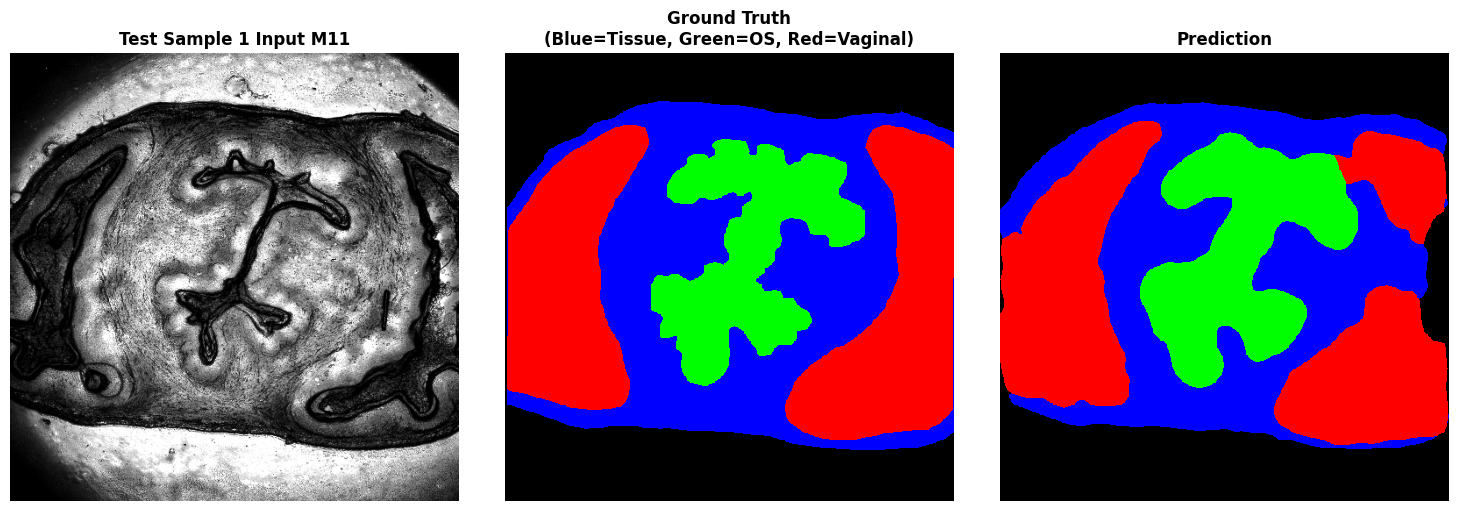

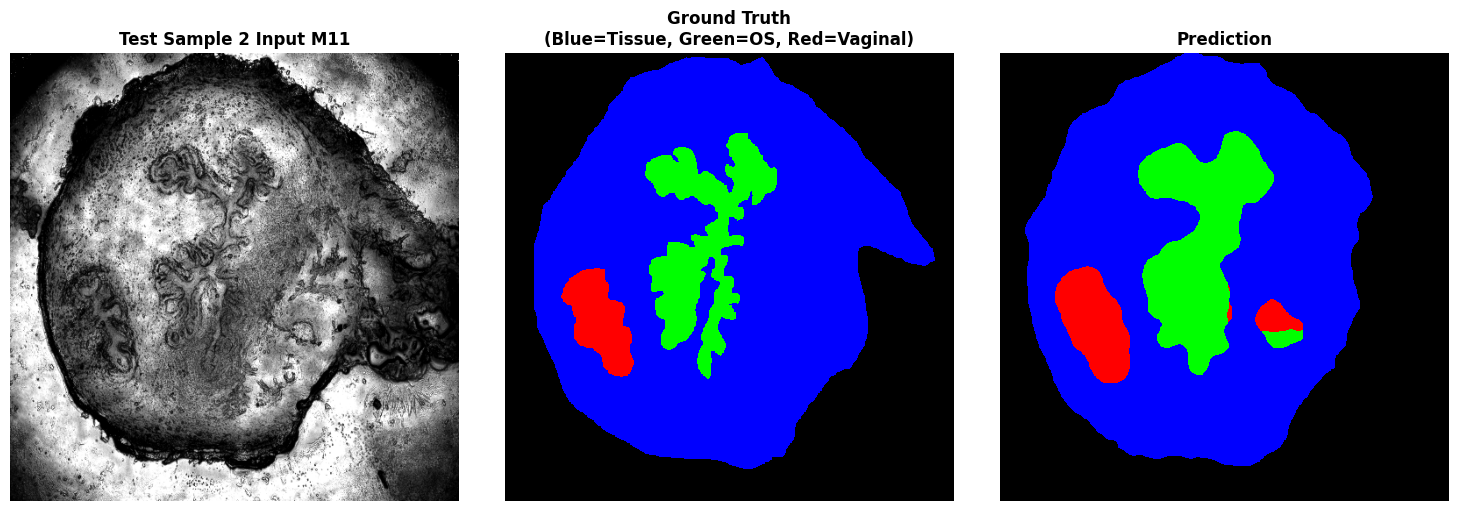

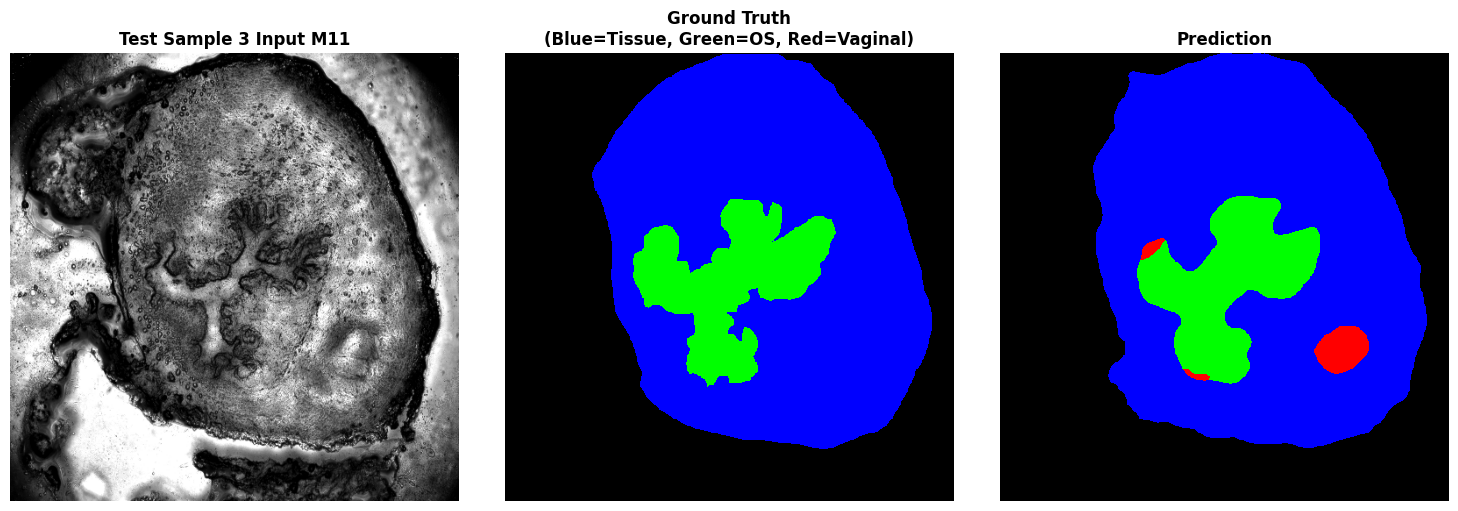


✓ Evaluation complete!


In [9]:
# Load best model
model.load_state_dict(torch.load(Config.OUTPUT_DIR / 'best_model.pth')['model_state_dict'])
model.eval()

# ==================== METRICS CALCULATION ====================

def calculate_metrics(loader, dataset_name="Test"):
    """Calculate comprehensive metrics"""
    all_preds = []
    all_targets = []
    
    print(f"\nEvaluating {dataset_name} Set...")
    with torch.no_grad():
        for img, mask in tqdm(loader, desc=f"{dataset_name} Inference"):
            img, mask = img.to(Config.DEVICE), mask.to(Config.DEVICE)
            pred = model(img)
            if pred.shape[-2:] != mask.shape[-2:]:
                pred = F.interpolate(pred, size=mask.shape[-2:])
            pred_class = torch.argmax(pred, dim=1)
            
            all_preds.append(pred_class.cpu().numpy())
            all_targets.append(mask.cpu().numpy())
    
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    
    # Overall accuracy
    accuracy = (all_preds == all_targets).mean()
    
    # Per-class IoU
    class_names = ['Background', 'Tissue', 'OS', 'Vaginal']
    ious = []
    
    print(f"\n{'='*60}")
    print(f"{dataset_name.upper()} SET RESULTS")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {accuracy*100:.2f}%")
    print(f"\nPer-Class IoU:")
    
    for class_id in range(num_classes):
        pred_mask = (all_preds == class_id)
        true_mask = (all_targets == class_id)
        
        intersection = (pred_mask & true_mask).sum()
        union = (pred_mask | true_mask).sum()
        
        if union > 0:
            iou = intersection / union
        else:
            iou = float('nan')
        
        ious.append(iou)
        if not np.isnan(iou):
            print(f"  Class {class_id} ({class_names[class_id]:10s}): {iou*100:.2f}%")
        else:
            print(f"  Class {class_id} ({class_names[class_id]:10s}): N/A (not present)")
    
    # Mean IoU (excluding NaN)
    valid_ious = [iou for iou in ious if not np.isnan(iou)]
    mean_iou = np.mean(valid_ious) if valid_ious else 0.0
    print(f"\nMean IoU: {mean_iou*100:.2f}%")
    print(f"{'='*60}\n")
    
    return accuracy, ious, mean_iou

# Evaluate test set
test_acc, test_ious, test_miou = calculate_metrics(test_loader, "Test")

# ==================== VISUALIZATION ====================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Define colormap
cmap_colors = ['black', 'blue', 'lime', 'red']
cmap = mcolors.ListedColormap(cmap_colors)
norm = mcolors.BoundaryNorm([0, 1, 2, 3, 4], cmap.N)

# ImageNet stats for denormalization
imagenet_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
imagenet_std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def visualize_prediction(dataset, idx, title_prefix=""):
    """Visualize a sample prediction"""
    img_tensor, mask_true = dataset[idx]

    # Run inference
    with torch.no_grad():
        input_tensor = img_tensor.unsqueeze(0).to(Config.DEVICE)
        pred = model(input_tensor)
        if pred.shape[-2:] != mask_true.shape[-2:]:
            pred = F.interpolate(pred, size=mask_true.shape[-2:])
        pred_mask = torch.argmax(pred, dim=1).cpu().squeeze().numpy()

    # Denormalize image
    img_np = img_tensor.numpy()  # [3, H, W]
    img_denorm = img_np * imagenet_std.reshape(3, 1, 1) + imagenet_mean.reshape(3, 1, 1)
    img_disp = img_denorm[0]  # Use first channel

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Input M11
    ax[0].imshow(img_disp, cmap='gray')
    ax[0].set_title(f"{title_prefix} Input M11", fontweight='bold')
    ax[0].axis('off')

    # Ground truth
    ax[1].imshow(mask_true, cmap=cmap, norm=norm, interpolation='nearest')
    ax[1].set_title("Ground Truth\n(Blue=Tissue, Green=OS, Red=Vaginal)", fontweight='bold')
    ax[1].axis('off')

    # Prediction
    ax[2].imshow(pred_mask, cmap=cmap, norm=norm, interpolation='nearest')
    ax[2].set_title("Prediction", fontweight='bold')
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / f'test_sample_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Visualize a few test samples
print("\nVisualizing Test Set Samples:")
for i in range(min(3, len(test_ds))):
    visualize_prediction(test_ds, i, f"Test Sample {i+1}")

print(f"\n✓ Evaluation complete!")

In [10]:
print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"Best Model Performance:")
print(f"  Validation Loss: {best_loss:.4f}")
print(f"  Validation Accuracy: {best_acc:.4f}")
print(f"\nTest Set Performance:")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Mean IoU: {test_miou:.4f}")
print(f"\nModel saved to: {Config.OUTPUT_DIR / 'best_model.pth'}")
print(f"Data split saved to: {Config.OUTPUT_DIR / 'data_split.json'}")
print("="*70)


TRAINING SUMMARY
Best Model Performance:
  Validation Loss: 0.3838
  Validation Accuracy: 0.9123

Test Set Performance:
  Test Accuracy: 0.9013
  Mean IoU: 0.7905

Model saved to: ..\..\models\best_model.pth
Data split saved to: ..\..\models\data_split.json


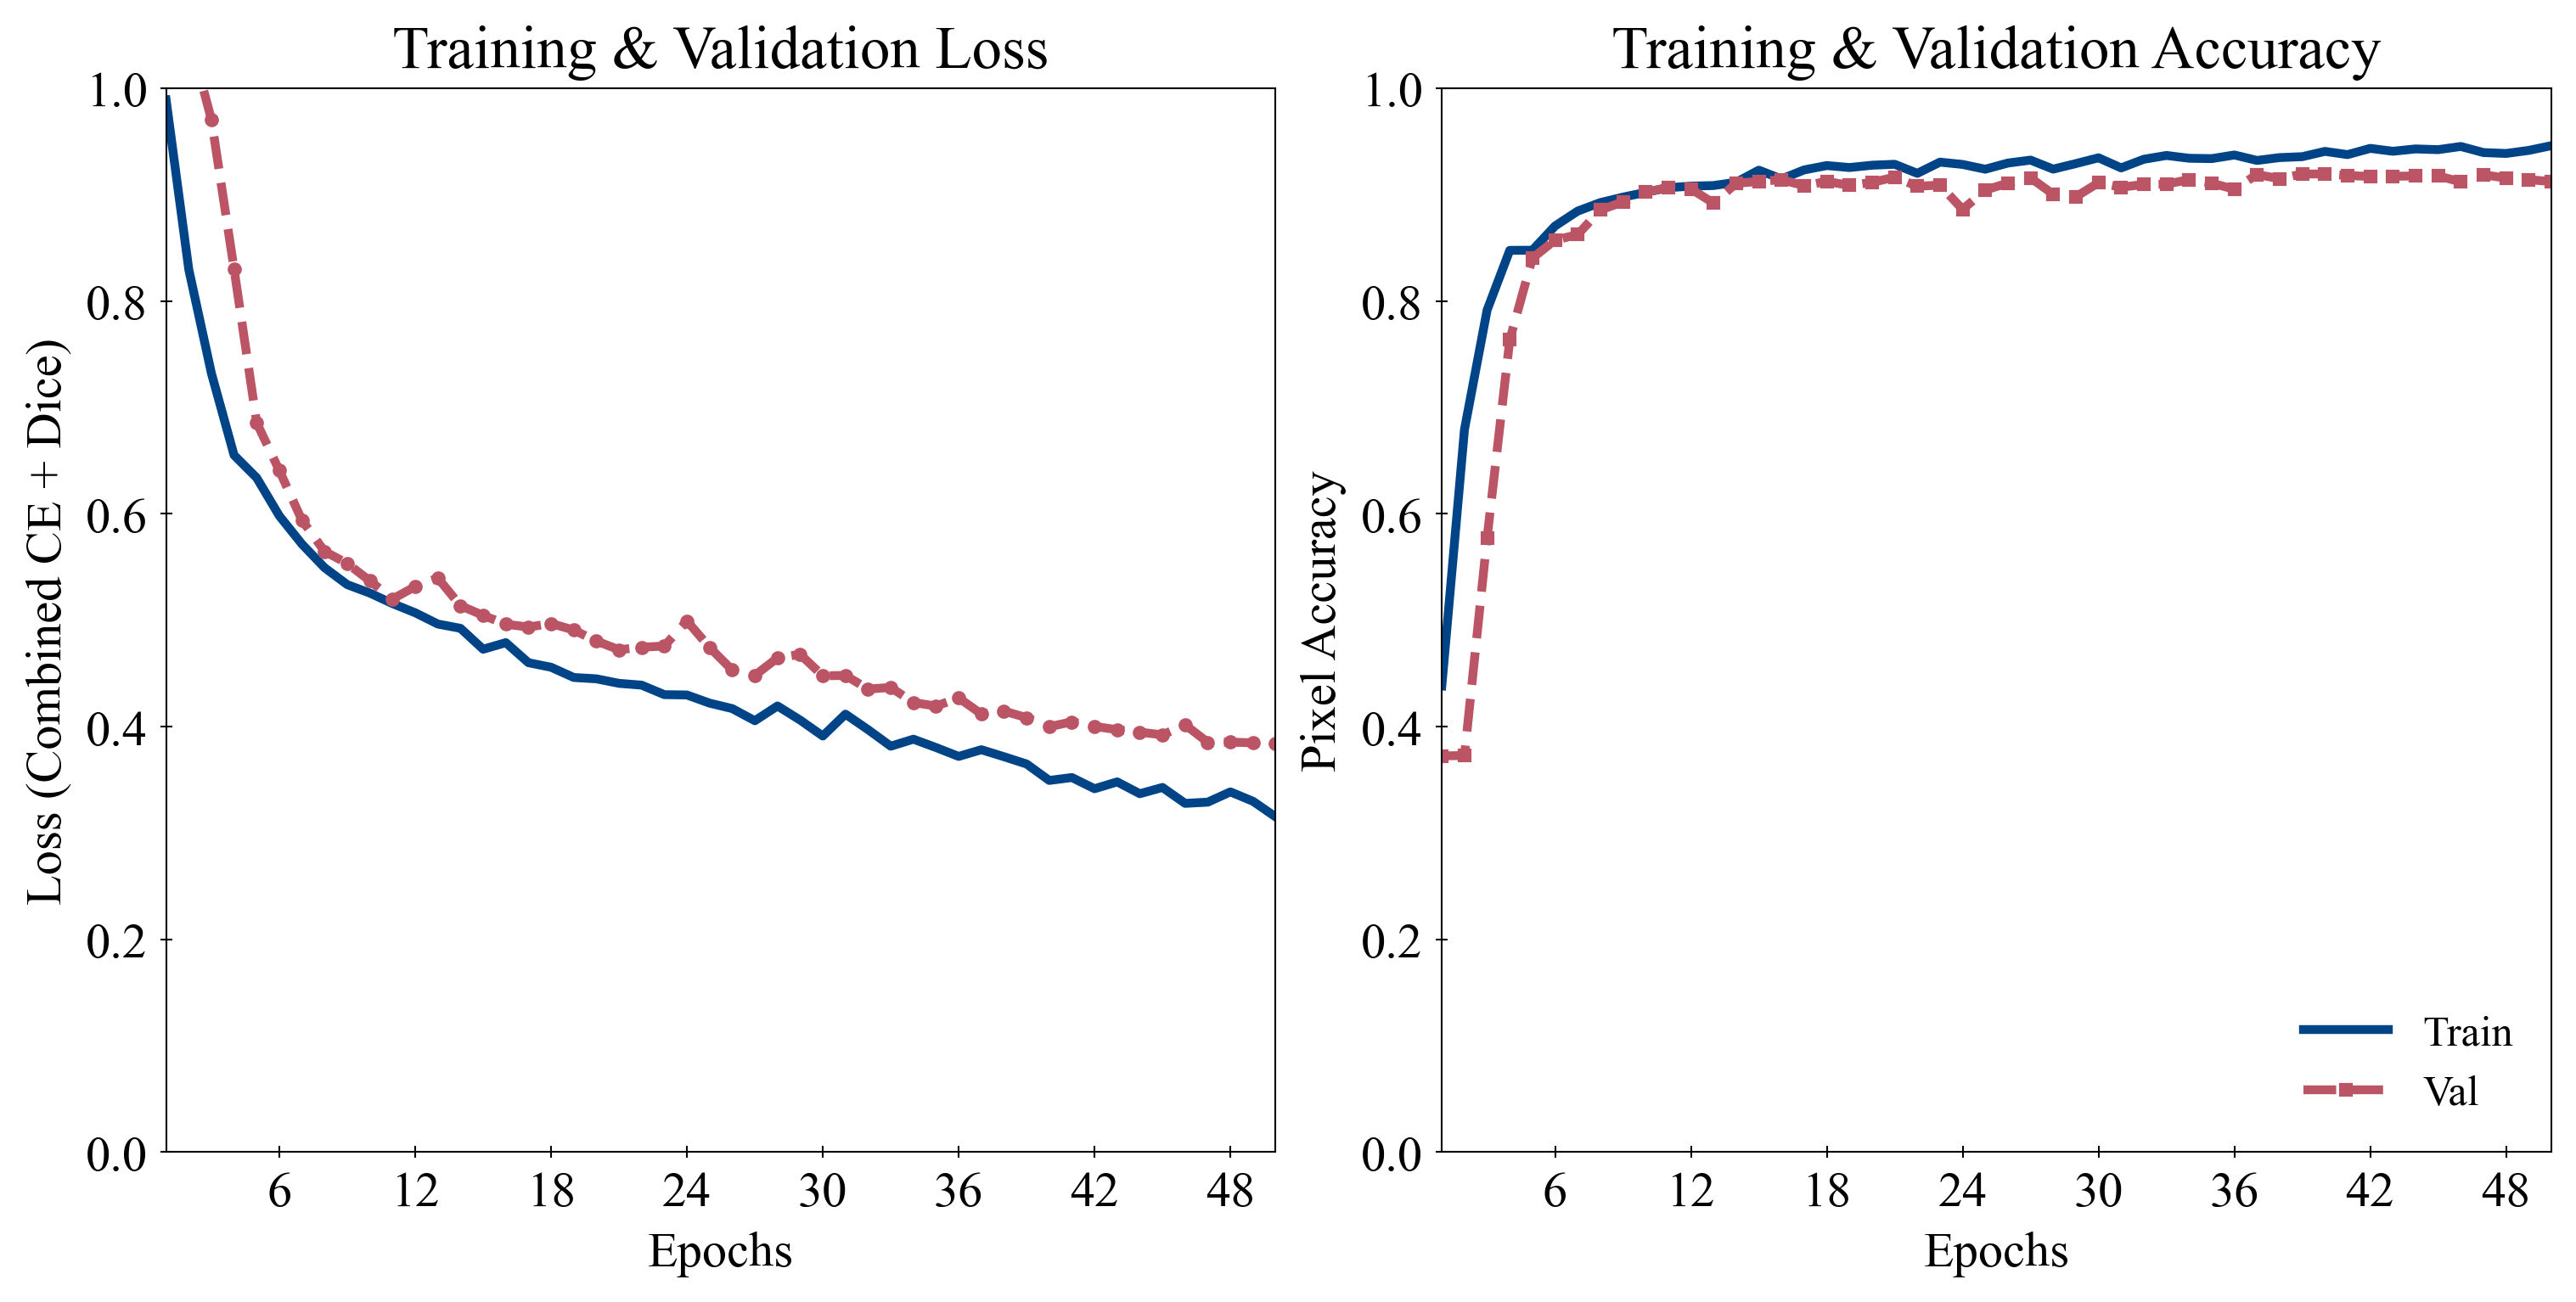

Figures saved to:
- ..\..\models\training_curves.png
- ..\..\models\training_curves.pdf


In [11]:
## 9. Visualization curves
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


def plot_publication_curves(history_df, output_dir):
    # 1. Setup Publication Style (Clean, High Contrast)
    plt.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman'],
        'font.size': 14,
        'axes.labelsize': 14,
        'axes.titlesize': 17,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12,
        'figure.dpi': 300,
        'lines.linewidth': 2.5,
        'axes.grid': False,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
    })

    # Reduced vertical height
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
    fig.patch.set_alpha(0.0)

    max_epoch = history_df['Epoch'].max()
    border_width = 0.5

    for ax in [ax1, ax2]:
        ax.patch.set_alpha(0.0)

        # Axis ranges and ticks
        ax.set_xlim(history_df['Epoch'].min(), max_epoch)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(6))

        # Fix Y-axis range to [0, 1]
        ax.set_ylim(0, 1)

        # Borders on all sides
        for side in ['bottom', 'left', 'top', 'right']:
            ax.spines[side].set_linewidth(border_width)
            ax.spines[side].set_color('black')
            ax.spines[side].set_visible(True)

        # Tick styling
        ax.tick_params(axis='x', colors='black', width=border_width, direction='inout')
        ax.tick_params(axis='y', colors='black', width=border_width, direction='inout')

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_color('black')

    # Plot 1: Loss (no legend here)
    ax1.plot(history_df['Epoch'], history_df['Train Loss'],
             color='#004488', linestyle='-', label='Train')

    ax1.plot(history_df['Epoch'], history_df['Val Loss'],
             color='#BB5566', linestyle='--', marker='o', markersize=3, label='Val')

    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss (Combined CE + Dice)')
    ax1.set_title('Training & Validation Loss')

    # Plot 2: Accuracy (only legend here)
    ax2.plot(history_df['Epoch'], history_df['Train Acc'],
             color='#004488', linestyle='-', label='Train')

    ax2.plot(history_df['Epoch'], history_df['Val Acc'],
             color='#BB5566', linestyle='--', marker='s', markersize=3, label='Val')

    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Pixel Accuracy')
    ax2.set_title('Training & Validation Accuracy')
    ax2.legend(frameon=False, loc='lower right')

    # Save with transparent background
    save_path = output_dir / 'training_curves.png'
    save_path_pdf = output_dir / 'training_curves.pdf'

    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(save_path_pdf, format='pdf', bbox_inches='tight', transparent=True)
    plt.show()

    print(f"Figures saved to:\n- {save_path}\n- {save_path_pdf}")


# Check if history_df exists
if 'history_df' in locals():
    plot_publication_curves(history_df, Config.OUTPUT_DIR)
else:
    print("Error: history_df not found. Please run the training loop block first.")